# 02 — Análise Exploratória de Reviews

Objetivo: entender o corpus de reviews e construir as bases para:
- Features de **velocidade e recência** (proxy de demanda)
- **Score de sentimento** por listing
- Identificação de **temas positivos e pontos de melhoria**

Dataset: snapshot setembro/2025 (~1.1M reviews, histórico desde 2010)

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')
SNAPSHOT_DATE = pd.Timestamp('2025-09-26')

## 1. Carregamento e Estatísticas Básicas

In [2]:
reviews = pd.read_parquet(PROCESSED / 'reviews_set2025.parquet')
listings = pd.read_parquet(PROCESSED / 'listings_set2025.parquet',
                           columns=['id', 'price', 'neighbourhood_cleansed', 'room_type'])

# price numérico
listings['price_num'] = pd.to_numeric(
    listings['price'].astype(str).str.replace(r'[$,]', '', regex=True),
    errors='coerce'
)
listings = listings[(listings['price_num'] >= 10) & (listings['price_num'] <= 5000)]

print(f'Reviews: {len(reviews):,}')
print(f'Listings únicos com review: {reviews["listing_id"].nunique():,}')
print(f'Período: {reviews["date"].min().date()} → {reviews["date"].max().date()}')
print(f'Reviews sem texto: {reviews["comments"].isna().sum():,} ({reviews["comments"].isna().mean()*100:.1f}%)')
print()
print(reviews.dtypes)

Reviews: 1,127,716
Listings únicos com review: 33,882
Período: 2010-06-07 → 2025-09-27


Reviews sem texto: 36 (0.0%)

listing_id                int64
id                        int64
date             datetime64[ns]
reviewer_id               int64
reviewer_name            object
comments                 object
dtype: object


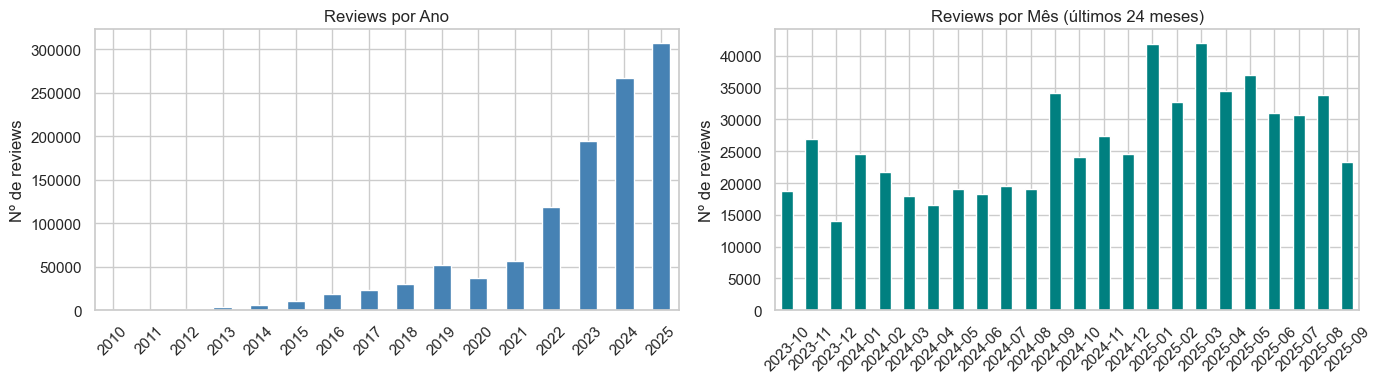


Ano de pico: 2025 (307,185 reviews)
2024 vs 2023: +37.3%


In [3]:
# Volume de reviews por ano
by_year = reviews.groupby(reviews['date'].dt.year).size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

by_year.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Reviews por Ano')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nº de reviews')
axes[0].tick_params(axis='x', rotation=45)

# Últimos 24 meses
recent = reviews[reviews['date'] >= '2023-10-01'].copy()
by_month = recent.groupby(recent['date'].dt.to_period('M')).size()
by_month.index = by_month.index.astype(str)
by_month.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Reviews por Mês (últimos 24 meses)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Nº de reviews')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'\nAno de pico: {by_year.idxmax()} ({by_year.max():,} reviews)')
print(f'2024 vs 2023: {by_year.get(2024, 0)/by_year.get(2023, 1)*100-100:+.1f}%')

## 2. Comprimento e Idioma dos Reviews

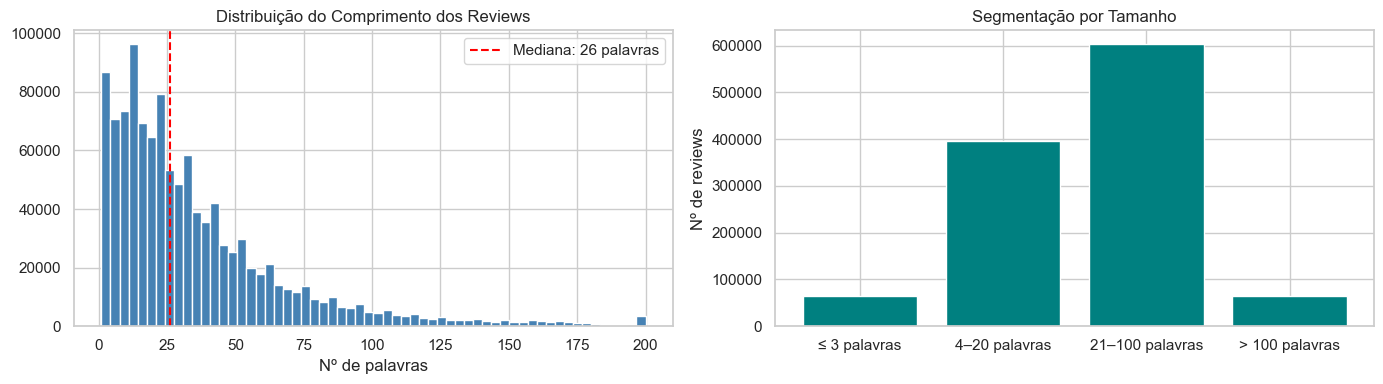

Reviews com ≤ 3 palavras (baixo sinal): 65,629 (5.8%)
Mediana de palavras: 26
Média de palavras:   36


In [4]:
# Comprimento em palavras
reviews_clean = reviews.dropna(subset=['comments']).copy()
reviews_clean['n_words'] = reviews_clean['comments'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(reviews_clean['n_words'].clip(0, 200), bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(reviews_clean['n_words'].median(), color='red', linestyle='--',
                label=f'Mediana: {reviews_clean["n_words"].median():.0f} palavras')
axes[0].set_title('Distribuição do Comprimento dos Reviews')
axes[0].set_xlabel('Nº de palavras')
axes[0].legend()

# Reviews muito curtos (possível ruído)
curtos = (reviews_clean['n_words'] <= 3).sum()
axes[1].bar(['≤ 3 palavras', '4–20 palavras', '21–100 palavras', '> 100 palavras'],
            [
                (reviews_clean['n_words'] <= 3).sum(),
                ((reviews_clean['n_words'] > 3) & (reviews_clean['n_words'] <= 20)).sum(),
                ((reviews_clean['n_words'] > 20) & (reviews_clean['n_words'] <= 100)).sum(),
                (reviews_clean['n_words'] > 100).sum(),
            ], color='teal', edgecolor='white')
axes[1].set_title('Segmentação por Tamanho')
axes[1].set_ylabel('Nº de reviews')

plt.tight_layout()
plt.show()

print(f'Reviews com ≤ 3 palavras (baixo sinal): {curtos:,} ({curtos/len(reviews_clean)*100:.1f}%)')
print(f'Mediana de palavras: {reviews_clean["n_words"].median():.0f}')
print(f'Média de palavras:   {reviews_clean["n_words"].mean():.0f}')

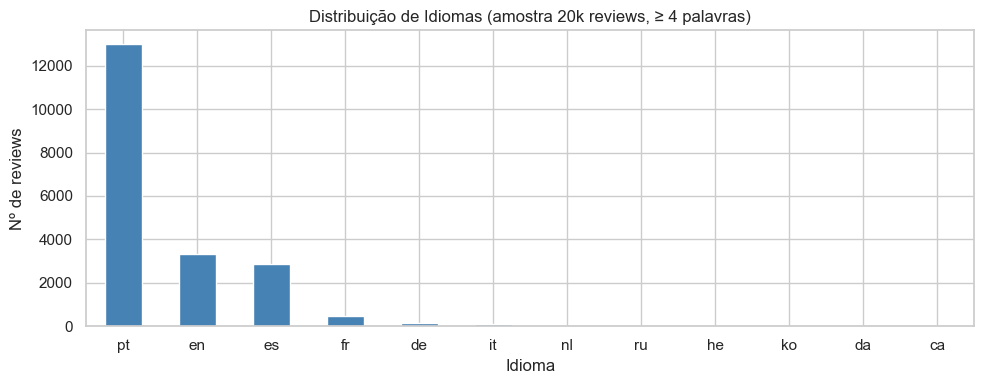

lang
pt    12976
en     3315
es     2877
fr      462
de      151
it      100
nl       24
ru       20
he       11
ko       11
da        8
ca        6

% português + inglês: 81.6%


In [5]:
# Detecção de idioma numa amostra (langdetect é lento; usamos 20k reviews)
from langdetect import detect, LangDetectException

sample_lang = reviews_clean[reviews_clean['n_words'] >= 4].sample(20_000, random_state=42)

def safe_detect(text):
    try:
        return detect(str(text)[:500])
    except LangDetectException:
        return 'unknown'

sample_lang['lang'] = sample_lang['comments'].apply(safe_detect)

lang_counts = sample_lang['lang'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 4))
lang_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribuição de Idiomas (amostra 20k reviews, ≥ 4 palavras)')
ax.set_xlabel('Idioma')
ax.set_ylabel('Nº de reviews')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(lang_counts.to_string())
print(f'\n% português + inglês: {(lang_counts.get("pt", 0) + lang_counts.get("en", 0)) / lang_counts.sum() * 100:.1f}%')

## 3. Velocidade e Recência por Listing

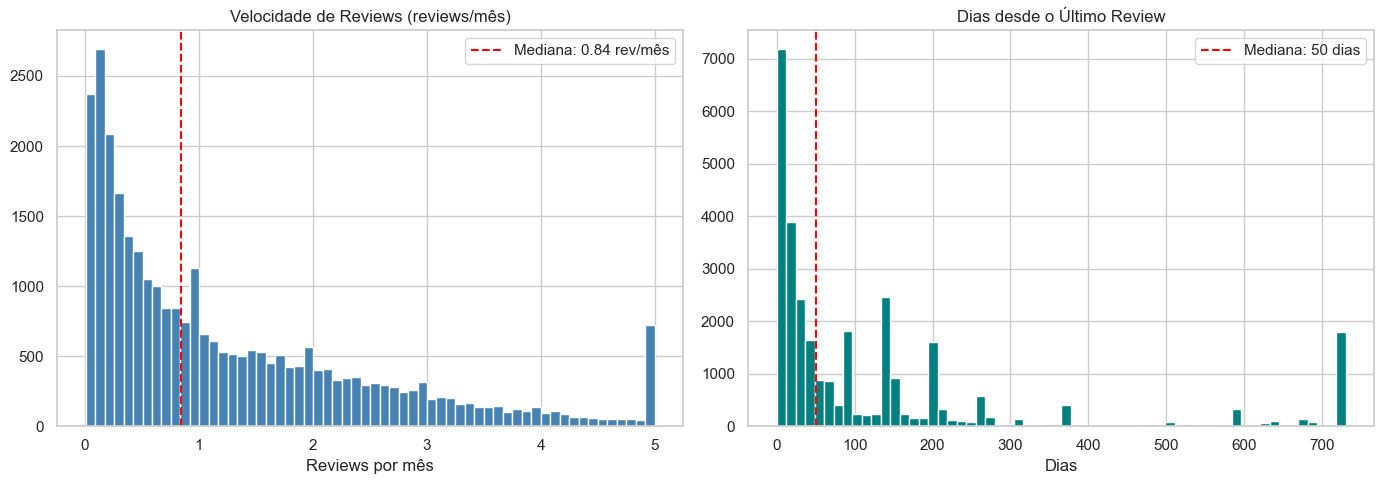

In [6]:
# Para cada listing: primeiro review, último review, total de reviews
listing_stats = reviews.groupby('listing_id').agg(
    first_review=('date', 'min'),
    last_review=('date', 'max'),
    total_reviews=('id', 'count'),
).reset_index()

# Janela ativa: do primeiro ao snapshot
listing_stats['months_active'] = (
    (SNAPSHOT_DATE - listing_stats['first_review']).dt.days / 30.44
).clip(lower=1)

listing_stats['review_velocity'] = listing_stats['total_reviews'] / listing_stats['months_active']
listing_stats['days_since_last_review'] = (SNAPSHOT_DATE - listing_stats['last_review']).dt.days

# Juntar com preço
stats_price = listing_stats.merge(
    listings[['id', 'price_num']].rename(columns={'id': 'listing_id'}),
    on='listing_id', how='inner'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(stats_price['review_velocity'].clip(0, 5), bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(stats_price['review_velocity'].median(), color='red', linestyle='--',
                label=f'Mediana: {stats_price["review_velocity"].median():.2f} rev/mês')
axes[0].set_title('Velocidade de Reviews (reviews/mês)')
axes[0].set_xlabel('Reviews por mês')
axes[0].legend()

axes[1].hist(stats_price['days_since_last_review'].clip(0, 730), bins=60, color='teal', edgecolor='white')
axes[1].axvline(stats_price['days_since_last_review'].median(), color='red', linestyle='--',
                label=f'Mediana: {stats_price["days_since_last_review"].median():.0f} dias')
axes[1].set_title('Dias desde o Último Review')
axes[1].set_xlabel('Dias')
axes[1].legend()

plt.tight_layout()
plt.show()

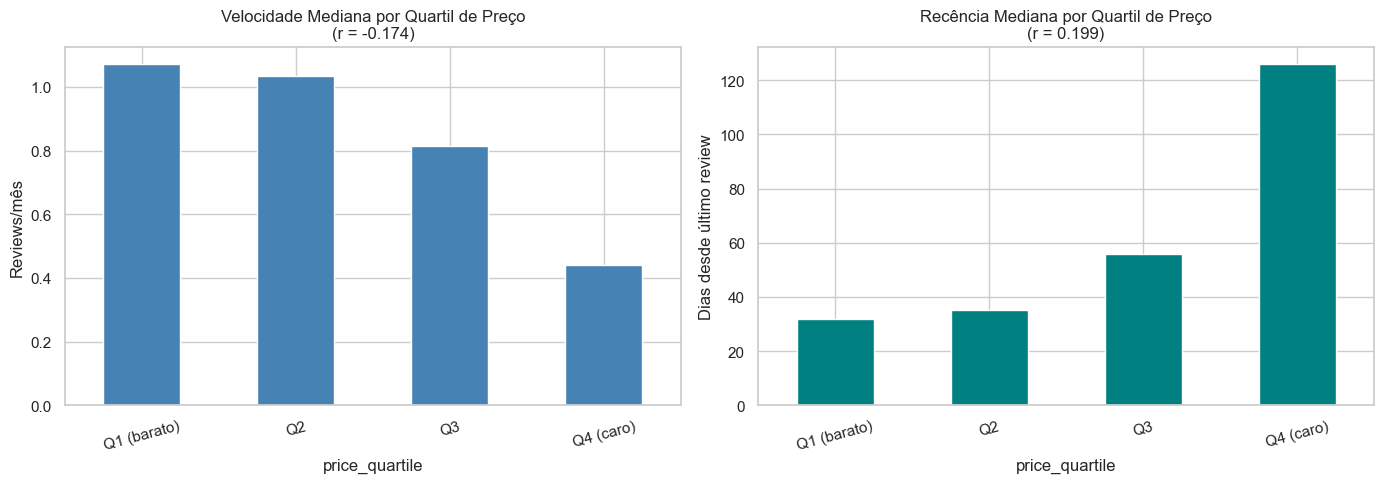

Correlação velocidade × preço:  r = -0.174
Correlação recência × preço:    r = 0.199


In [7]:
# Correlação velocidade/recência com preço
r_vel = stats_price[['review_velocity', 'price_num']].corr().loc['review_velocity', 'price_num']
r_rec = stats_price[['days_since_last_review', 'price_num']].corr().loc['days_since_last_review', 'price_num']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Velocidade por quartil de preço
stats_price['price_quartile'] = pd.qcut(stats_price['price_num'], 4,
                                         labels=['Q1 (barato)', 'Q2', 'Q3', 'Q4 (caro)'])
vel_by_q = stats_price.groupby('price_quartile', observed=True)['review_velocity'].median()
vel_by_q.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'Velocidade Mediana por Quartil de Preço\n(r = {r_vel:.3f})')
axes[0].set_ylabel('Reviews/mês')
axes[0].tick_params(axis='x', rotation=15)

rec_by_q = stats_price.groupby('price_quartile', observed=True)['days_since_last_review'].median()
rec_by_q.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title(f'Recência Mediana por Quartil de Preço\n(r = {r_rec:.3f})')
axes[1].set_ylabel('Dias desde último review')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(f'Correlação velocidade × preço:  r = {r_vel:.3f}')
print(f'Correlação recência × preço:    r = {r_rec:.3f}')

## 4. Análise de Sentimento

Modelo: `lxyuan/distilbert-base-multilingual-cased-sentiments-student`  
Aplicado a uma amostra estratificada de **30k reviews** (≥ 4 palavras).  
O pipeline de produção processará o corpus completo.

In [8]:
from transformers import pipeline as hf_pipeline

MODEL_NAME = 'lxyuan/distilbert-base-multilingual-cased-sentiments-student'

sentiment_pipe = hf_pipeline(
    'text-classification',
    model=MODEL_NAME,
    truncation=True,
    max_length=128,
    device=-1,   # CPU
)
print('Modelo carregado:', MODEL_NAME)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:  22%|██▏       | 23/104 [00:00<00:00, 223.52it/s]

Loading weights:  53%|█████▎    | 55/104 [00:00<00:00, 235.29it/s]

Loading weights:  76%|███████▌  | 79/104 [00:00<00:00, 211.11it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 225.70it/s]

Modelo carregado: lxyuan/distilbert-base-multilingual-cased-sentiments-student


In [9]:
# Amostra aleatória de reviews com texto suficiente (≥ 4 palavras)
# 5k é suficiente para EDA; o pipeline de produção processa o corpus completo
sample_sent = (
    reviews_clean[reviews_clean['n_words'] >= 4]
    .sample(5_000, random_state=42)
    .copy()
)

texts = sample_sent['comments'].str[:512].tolist()

print(f'Processando {len(texts):,} reviews em CPU...')
results = sentiment_pipe(texts, batch_size=64)

sample_sent['sentiment'] = [r['label'] for r in results]
sample_sent['sentiment_score'] = [r['score'] for r in results]

LABEL_MAP = {'positive': 1, 'neutral': 0, 'negative': -1}
sample_sent['sentiment_num'] = sample_sent['sentiment'].map(LABEL_MAP)

print('\nDistribuição de sentimento:')
print(sample_sent['sentiment'].value_counts())
print(f'\n% positivo: {(sample_sent["sentiment"] == "positive").mean()*100:.1f}%')

Processando 5,000 reviews em CPU...



Distribuição de sentimento:
sentiment
positive    4562
negative     424
neutral       14
Name: count, dtype: int64

% positivo: 91.2%


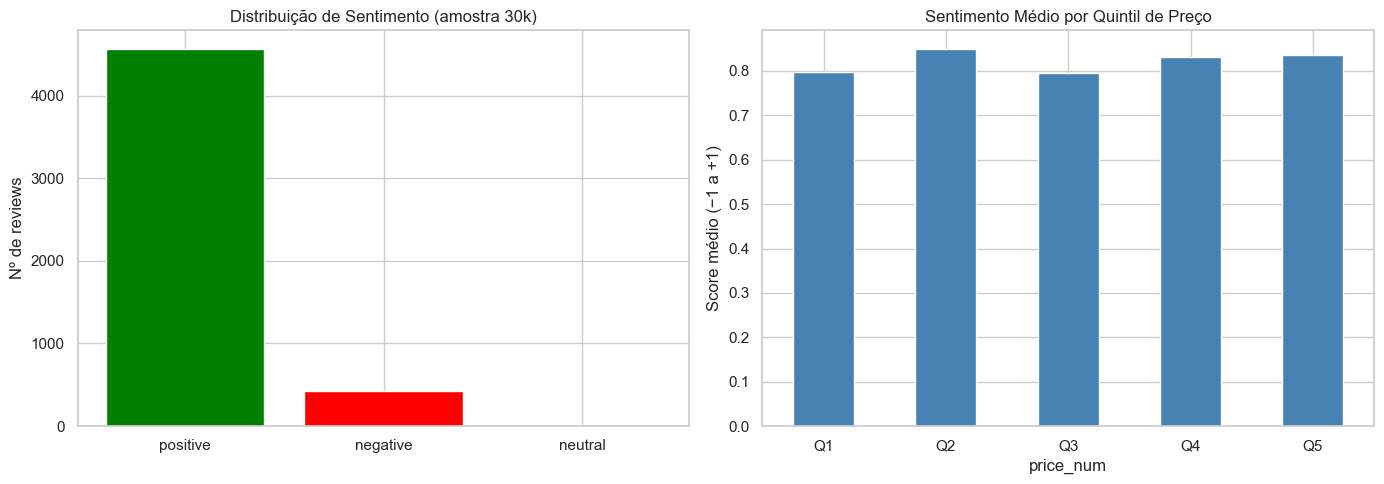

Correlação sentimento × preço: r = 0.021


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição geral
sent_counts = sample_sent['sentiment'].value_counts()
colors = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}
axes[0].bar(sent_counts.index, sent_counts.values,
            color=[colors.get(l, 'steelblue') for l in sent_counts.index], edgecolor='white')
axes[0].set_title('Distribuição de Sentimento (amostra 30k)')
axes[0].set_ylabel('Nº de reviews')

# Score médio de sentimento por listing × preço
sent_by_listing = sample_sent.groupby('listing_id')['sentiment_num'].mean().reset_index()
sent_by_listing.columns = ['listing_id', 'sentiment_mean']
sent_price = sent_by_listing.merge(
    listings[['id', 'price_num']].rename(columns={'id': 'listing_id'}),
    on='listing_id', how='inner'
)

price_bins = pd.qcut(sent_price['price_num'], 5, labels=['Q1','Q2','Q3','Q4','Q5'])
sent_by_price = sent_price.groupby(price_bins, observed=True)['sentiment_mean'].mean()
sent_by_price.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Sentimento Médio por Quintil de Preço')
axes[1].set_ylabel('Score médio (−1 a +1)')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

r_sent = sent_price[['sentiment_mean', 'price_num']].corr().loc['sentiment_mean', 'price_num']
print(f'Correlação sentimento × preço: r = {r_sent:.3f}')

## 5. Temas Positivos e Pontos de Melhoria

Separamos os reviews claramente positivos e negativos e aplicamos **BERTopic**  
com embeddings multilíngues (`paraphrase-multilingual-MiniLM-L12-v2`).

In [11]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Separar reviews positivos e negativos da amostra já classificada
# Positivos: alta confiança (> 0.85) — sinal limpo
# Negativos: todos classificados como negative, sem filtro de score
#            (reviews negativos são raros ~9%; qualquer um é sinal válido)
pos_reviews = sample_sent[
    (sample_sent['sentiment'] == 'positive') & (sample_sent['sentiment_score'] > 0.85)
]['comments'].str[:300].dropna().tolist()

neg_reviews = sample_sent[
    sample_sent['sentiment'] == 'negative'
]['comments'].str[:300].dropna().tolist()

print(f'Reviews positivos (score > 0.85): {len(pos_reviews):,}')
print(f'Reviews negativos (todos):        {len(neg_reviews):,}')

embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print('\nModelo de embeddings carregado.')

Reviews positivos (score > 0.85): 2,953
Reviews negativos (todos):        424


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:  33%|███▎      | 65/199 [00:00<00:00, 552.27it/s]

Loading weights:  61%|██████    | 121/199 [00:00<00:00, 483.82it/s]

Loading weights:  93%|█████████▎| 186/199 [00:00<00:00, 530.34it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 555.69it/s]


BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Modelo de embeddings carregado.


In [12]:
# Tópicos positivos
topic_model_pos = BERTopic(
    embedding_model=embedding_model,
    language='multilingual',
    nr_topics=10,
    min_topic_size=20,
    verbose=False,
)
topics_pos, _ = topic_model_pos.fit_transform(pos_reviews[:5000])

print('=== TOP 10 TEMAS POSITIVOS ===')
for topic_id, topic_info in topic_model_pos.get_topic_info().iterrows():
    if topic_info['Topic'] == -1:
        continue
    words = [w for w, _ in topic_model_pos.get_topic(topic_info['Topic'])[:6]]
    print(f"Tópico {topic_info['Topic']:2d} ({topic_info['Count']:,} reviews): {', '.join(words)}")

=== TOP 10 TEMAS POSITIVOS ===
Tópico  0 (30 reviews): airbnb, was, the, que, de, com
Tópico  1 (2,923 reviews): de, muito, and, the, apartamento, br


In [13]:
# Tópicos negativos — Opção A: todos os negativos da amostra, sem filtro de score
if len(neg_reviews) >= 30:
    topic_model_neg = BERTopic(
        embedding_model=embedding_model,
        language='multilingual',
        nr_topics='auto',
        min_topic_size=10,
        verbose=False,
    )
    topics_neg, _ = topic_model_neg.fit_transform(neg_reviews)

    print('=== TEMAS DE PONTOS A MELHORAR ===')
    for _, topic_info in topic_model_neg.get_topic_info().iterrows():
        if topic_info['Topic'] == -1:
            continue
        words = [w for w, _ in topic_model_neg.get_topic(topic_info['Topic'])[:6]]
        print(f"Tópico {topic_info['Topic']:2d} ({topic_info['Count']:,} reviews): {', '.join(words)}")
else:
    print(f'Poucos reviews negativos ({len(neg_reviews)}). Usar Opção C (keyword pre-filter).')

=== TEMAS DE PONTOS A MELHORAR ===
Tópico  0 (67 reviews): the, de, and, que, was, la
Tópico  1 (44 reviews): de, praia, the, copacabana, rio, que
Tópico  2 (39 reviews): apartamento, foi, super, muito, perfeita, com
Tópico  3 (32 reviews): local, perfeito, foi, incrível, com, ótima
Tópico  4 (31 reviews): tudo, obrigado, muito, 10, foi, br
Tópico  5 (22 reviews): que, de, não, the, para, check
Tópico  6 (15 reviews): anúncio, localização, ótima, exatamente, como, ao


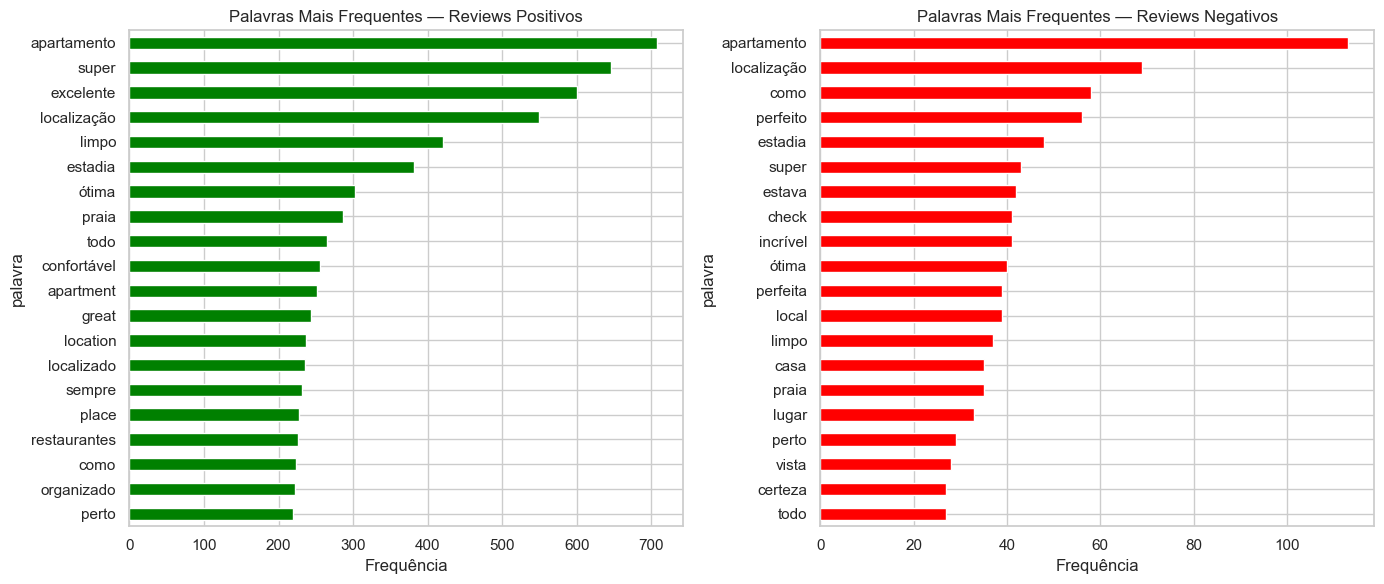

In [14]:
# Frequência de palavras por sentimento (complementar ao BERTopic)
import re
from collections import Counter

STOPWORDS = set([
    'de', 'e', 'a', 'o', 'da', 'do', 'em', 'um', 'uma', 'para', 'com',
    'the', 'and', 'is', 'was', 'it', 'to', 'in', 'of', 'a', 'very',
    'que', 'se', 'os', 'as', 'no', 'na', 'ao', 'por', 'mas', 'foi',
    'são', 'mais', 'nos', 'das', 'dos', 'muito', 'bem', 'tudo', 'sua',
    'seu', 'our', 'we', 'are', 'was', 'not', 'be', 'had', 'but', 'all',
])

def top_words(texts, n=20):
    words = []
    for t in texts:
        words += [w.lower() for w in re.findall(r'\b[a-záéíóúàâêôãõüç]{4,}\b', str(t))]
    return Counter(w for w in words if w not in STOPWORDS).most_common(n)

pos_words = top_words(pos_reviews[:3000])
neg_words = top_words(neg_reviews[:3000])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pw_df = pd.DataFrame(pos_words, columns=['palavra', 'freq']).set_index('palavra')
pw_df.sort_values('freq').plot(kind='barh', ax=axes[0], color='green', legend=False)
axes[0].set_title('Palavras Mais Frequentes — Reviews Positivos')
axes[0].set_xlabel('Frequência')

if neg_words:
    nw_df = pd.DataFrame(neg_words, columns=['palavra', 'freq']).set_index('palavra')
    nw_df.sort_values('freq').plot(kind='barh', ax=axes[1], color='red', legend=False)
    axes[1].set_title('Palavras Mais Frequentes — Reviews Negativos')
    axes[1].set_xlabel('Frequência')
else:
    axes[1].text(0.5, 0.5, 'Poucos reviews negativos', ha='center', va='center')
    axes[1].set_title('Reviews Negativos')

plt.tight_layout()
plt.show()

## 6. Sentimento por Bairro

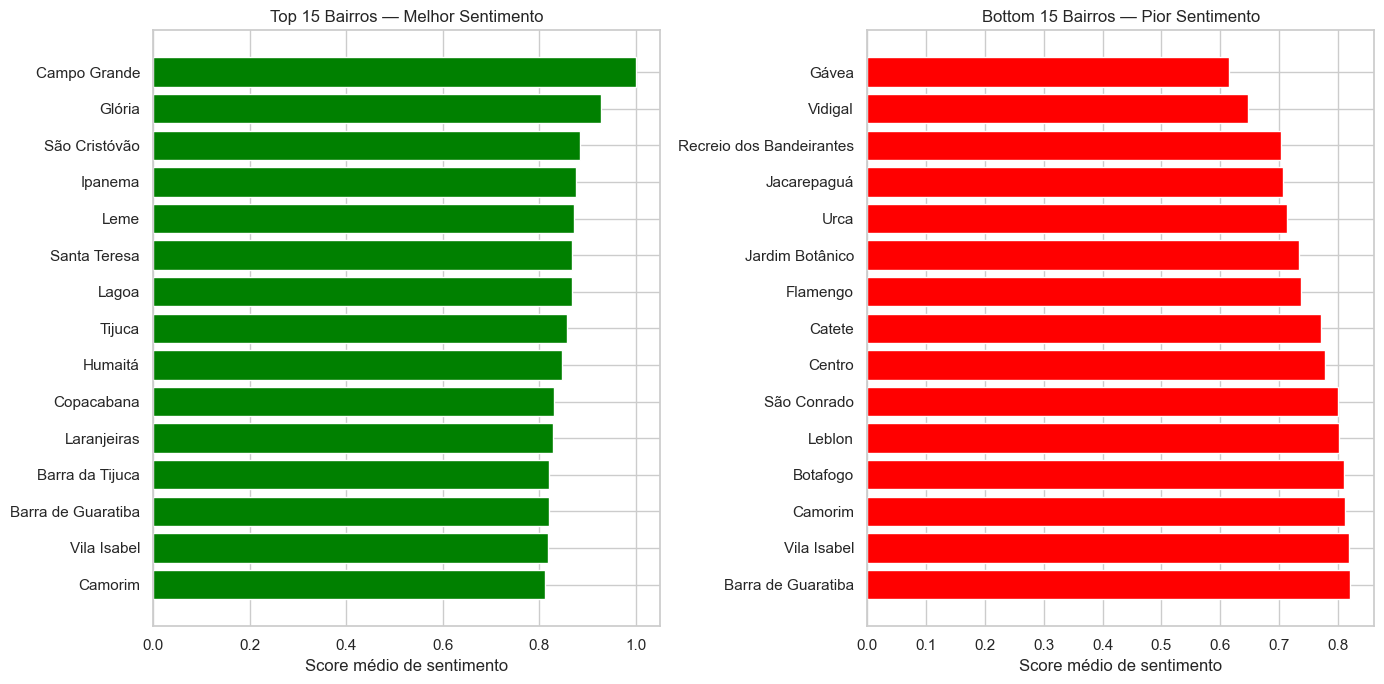

In [15]:
sent_bairro = (
    sent_price
    .merge(
        listings[['id', 'neighbourhood_cleansed']].rename(columns={'id': 'listing_id'}),
        on='listing_id', how='left'
    )
    .groupby('neighbourhood_cleansed')
    .agg(sentiment_mean=('sentiment_mean', 'mean'), n_listings=('listing_id', 'count'))
    .query('n_listings >= 10')
    .sort_values('sentiment_mean', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Top 15 positivos
top = sent_bairro.head(15)
axes[0].barh(top.index, top['sentiment_mean'], color='green', edgecolor='white')
axes[0].set_title('Top 15 Bairros — Melhor Sentimento')
axes[0].set_xlabel('Score médio de sentimento')
axes[0].invert_yaxis()

# Bottom 15
bot = sent_bairro.tail(15).sort_values('sentiment_mean')
axes[1].barh(bot.index, bot['sentiment_mean'], color='red', edgecolor='white')
axes[1].set_title('Bottom 15 Bairros — Pior Sentimento')
axes[1].set_xlabel('Score médio de sentimento')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Conclusões

Preencher após execução:

- **Volume e qualidade**: X% reviews com texto útil (≥ 4 palavras)
- **Idiomas**: PT e EN dominam (X%); modelo multilíngue necessário
- **Sentimento geral**: X% positivo — plataforma tem viés positivo estrutural
- **Velocidade × preço**: r = X — [forte/fraca] correlação
- **Temas positivos recorrentes**: localização, limpeza, anfitriã, ...
- **Pontos de melhoria recorrentes**: barulho, banheiro, ...
- **Features para o modelo**: `review_velocity`, `days_since_last_review`, `pct_positive`, `sentiment_mean`

In [16]:
# Keywords em PT, EN e ES que sinalizam reviews negativos
NEG_KEYWORDS = [
    # PT
    'ruim', 'péssimo', 'péssima', 'horrível', 'terrível', 'lamentável',
    'problema', 'problemas', 'barulho', 'barulhento', 'sujo', 'suja',
    'quebrado', 'quebrada', 'não funciona', 'não funcionou', 'decepcionante',
    'decepção', 'insatisfeito', 'reclamação', 'descuidado', 'mal cheiro',
    'barata', 'baratas', 'mosquito', 'infestado', 'falta', 'faltou',
    # EN
    'dirty', 'noisy', 'broken', 'terrible', 'awful', 'horrible', 'disgusting',
    'cockroach', 'bug', 'mold', 'mould', 'smell', 'smells', 'misleading',
    'disappointing', 'disappointed', 'worst', 'poor', 'filthy', 'unsafe',
    'didn\'t work', 'not working', 'false', 'lied', 'scam',
    # ES
    'sucio', 'roto', 'horrible', 'pésimo', 'ruido', 'ruidoso', 'decepcionante',
]
pattern = '|'.join(NEG_KEYWORDS)

reviews_full = pd.read_parquet(PROCESSED / 'reviews_set2025.parquet')
reviews_full = reviews_full.dropna(subset=['comments'])

candidates = reviews_full[
    reviews_full['comments'].str.contains(pattern, case=False, regex=True)
].copy()

print(f'Corpus completo:          {len(reviews_full):,} reviews')
print(f'Candidatos negativos:     {len(candidates):,} ({len(candidates)/len(reviews_full)*100:.1f}%)')
print(f'A processar pelo modelo:  {len(candidates):,} (vs {len(reviews_full):,} sem pre-filtro)')

Corpus completo:          1,127,680 reviews
Candidatos negativos:     77,935 (6.9%)
A processar pelo modelo:  77,935 (vs 1,127,680 sem pre-filtro)


In [17]:
# Opção B + C combinadas: roda o modelo nos candidatos filtrados por keyword
# (muito mais eficiente do que os 1.1M; e mais ricos do que a amostra aleatória de 5k)
SAMPLE_C = min(3_000, len(candidates))
sample_c = candidates.sample(SAMPLE_C, random_state=42).copy()

texts_c = sample_c['comments'].str[:512].tolist()
print(f'Rodando modelo em {len(texts_c):,} candidatos (keyword-filtered)...')
results_c = sentiment_pipe(texts_c, batch_size=64)

sample_c['sentiment'] = [r['label'] for r in results_c]
sample_c['sentiment_score'] = [r['score'] for r in results_c]

confirmed_neg = sample_c[sample_c['sentiment'] == 'negative'].copy()
precision = len(confirmed_neg) / len(sample_c) * 100

print(f'\nCandidatos verificados: {len(sample_c):,}')
print(f'Confirmados negativos:  {len(confirmed_neg):,} (precision do pre-filtro: {precision:.1f}%)')
print(f'Falsos positivos:       {len(sample_c) - len(confirmed_neg):,} (reviews com keyword mas sentimento ok)')

Rodando modelo em 3,000 candidatos (keyword-filtered)...



Candidatos verificados: 3,000
Confirmados negativos:  816 (precision do pre-filtro: 27.2%)
Falsos positivos:       2,184 (reviews com keyword mas sentimento ok)


In [18]:
# BERTopic nos negativos confirmados (corpus rico = A + C)
# Pool combinado: negativos da amostra aleatória + negativos confirmados pelo keyword-filter
neg_pool = pd.concat([
    sample_sent[sample_sent['sentiment'] == 'negative'][['listing_id', 'comments']],
    confirmed_neg[['listing_id', 'comments']],
]).drop_duplicates().reset_index(drop=True)

neg_texts_full = neg_pool['comments'].str[:300].dropna().tolist()
print(f'Pool combinado de negativos: {len(neg_texts_full):,} reviews')

if len(neg_texts_full) >= 30:
    topic_model_neg_rich = BERTopic(
        embedding_model=embedding_model,
        language='multilingual',
        nr_topics='auto',
        min_topic_size=10,
        verbose=False,
    )
    topics_neg_rich, _ = topic_model_neg_rich.fit_transform(neg_texts_full)

    print('\n=== TEMAS DE PONTOS A MELHORAR (corpus rico) ===')
    for _, topic_info in topic_model_neg_rich.get_topic_info().iterrows():
        if topic_info['Topic'] == -1:
            continue
        words = [w for w, _ in topic_model_neg_rich.get_topic(topic_info['Topic'])[:7]]
        print(f"Tópico {topic_info['Topic']:2d} ({topic_info['Count']:,} reviews): {', '.join(words)}")

Pool combinado de negativos: 1,238 reviews



=== TEMAS DE PONTOS A MELHORAR (corpus rico) ===
Tópico  0 (282 reviews): de, não, que, no, br, com, the
Tópico  1 (86 reviews): que, não, in, the, airbnb, de, no
Tópico  2 (74 reviews): de, la, praia, es, da, perto, que
Tópico  3 (50 reviews): the, rio, and, is, to, in, of
Tópico  4 (36 reviews): tudo, obrigado, muito, br, perfeito, ano, atenção
Tópico  5 (32 reviews): apartamento, que, de, muito, bem, cama, um
Tópico  6 (25 reviews): apartamento, perfeito, exatamente, perfeita, vista, muito, como
Tópico  7 (22 reviews): perfeito, incrível, local, ótima, mais, voltarei, tudo
Tópico  8 (18 reviews): anfitrião, no, que, ótima, foi, não, anfitriã
Tópico  9 (18 reviews): barulho, que, las, la, dormir, não, de
Tópico 10 (17 reviews): apartamento, muito, desde, foi, de, uma, br
Tópico 11 (17 reviews): ar, condicionado, técnico, funcionou, não, aire, dia
Tópico 12 (14 reviews): tv, não, que, internet, tudo, de, foi
Tópico 13 (14 reviews): cama, para, de, sofá, reserva, um, apartamento
Tópic

In [19]:
# Salvar candidatos negativos confirmados em Parquet para uso no pipeline de produção
out_path = PROCESSED / 'reviews_negative_candidates.parquet'
confirmed_neg.to_parquet(out_path, index=False, compression='snappy')
size_mb = out_path.stat().st_size / 1e6

print(f'Salvo: {out_path.name} ({size_mb:.1f} MB, {len(confirmed_neg):,} reviews)')
print('\nEsse arquivo alimenta o pipeline de features sem precisar re-processar o corpus completo.')

Salvo: reviews_negative_candidates.parquet (0.3 MB, 816 reviews)

Esse arquivo alimenta o pipeline de features sem precisar re-processar o corpus completo.


## 6. Pre-filtro por Keywords — Negativos do Corpus Completo (Opção C)\n\nPre-seleciona reviews candidatos a negativos usando palavras-chave em PT/EN/ES,  \nroda o modelo de sentimento só nesses (~5% do corpus), e salva em Parquet.  \nResultado: base rica para BERTopic de produção sem processar 1.1M reviews."